In [1]:
import gc
import os
from pathlib import Path
import random
import sys

from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import scipy as sp


import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from datetime import timedelta
from IPython.core.display import display, HTML

# --- plotly ---
from plotly import tools, subplots
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
import plotly.io as pio
pio.templates.default = "plotly_dark"

# --- models ---
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from scipy import integrate, optimize
from sklearn.metrics import mean_squared_log_error

import tensorflow.compat.v1 as tf 
from tensorflow.keras import layers
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Concatenate, Embedding, Reshape, Flatten, Conv1D, Conv2D, MaxPooling1D, AveragePooling1D, BatchNormalization

# --- setup ---
#pd.set_option('max_columns', 50)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
config = tf.ConfigProto()

config.gpu_options.allow_growth = True
session = tf.Session(config=config)

C:\Users\user\AppData\Local\Temp\ipykernel_22412\615312040.py:17: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning:

Unable to find acceptable character detection dependency (chardet or charset_normalizer).



In [2]:
all_df = pd.read_csv("data/owid-covid-data-old.csv",  keep_default_na=False)
population_ =pd.read_csv('data/population_by_country_2020.xls', sep=',')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1426435411.py:1: DtypeWarning:

Columns (4,7,8,9,10,13,14,15,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
population_.loc[population_['Country (or dependency)'] == 'United States', 'Country (or dependency)'] = "US"
population_.loc[population_['Country (or dependency)'] == 'South Korea', 'Country (or dependency)'] = "Korea, South"
population_.loc[population_['Country (or dependency)'] == 'Sao Tome & Principe', 'Country (or dependency)'] = "Sao Tome and Principe"
population_.loc[population_['Country (or dependency)'] == 'Taiwan', 'Country (or dependency)'] = "Taiwan*"

population_.loc[population_['Country (or dependency)'] == 'Myanmar', 'Country (or dependency)'] = "Burma"
population_.loc[population_['Country (or dependency)'] == 'Congo', 'Country (or dependency)'] = "Congo (Brazzaville)"
population_.loc[population_['Country (or dependency)'] == 'DR Congo', 'Country (or dependency)'] = "Congo (Kinshasa)"
population_.loc[population_['Country (or dependency)'] == "Côte d'Ivoire", 'Country (or dependency)'] = "Cote d'Ivoire"

population_.loc[population_['Country (or dependency)'] == 'Czech Republic (Czechia)', 'Country (or dependency)'] = "Czechia"
population_.loc[population_['Country (or dependency)'] == 'Saint Kitts & Nevis', 'Country (or dependency)'] = "Saint Kitts and Nevis"
population_.loc[population_['Country (or dependency)'] == 'St. Vincent & Grenadines', 'Country (or dependency)'] = "Saint Vincent and the Grenadines"


population_.rename({'Population (2020)': 'population', 'Country (or dependency)': 'country', 'Yearly Change': 'yearly_change', 
                 'Net Change': 'net_change', 'Density (P/Km²)': 'density', 'Land Area (Km²)': 'land_area', 
                 'Migrants (net)': 'migrants', 'Fert. Rate': 'rert_rate', 'Med. Age': 'med_age', 
                 'Urban Pop %': 'urban_pop', 'World Share': 'world_share'}, axis=1, inplace=True)
population_["yearly_change"] = population_["yearly_change"].apply(lambda x: x.replace(" ", "").replace("%","")).astype("float")
population_["urban_pop"] = population_["urban_pop"].apply(lambda x: x.replace(" ", "").replace("N.A.","0").replace("%","")).astype("float")
population_["world_share"] = population_["world_share"].apply(lambda x: x.replace(" ", "").replace("%","")).astype("float")

population_["rert_rate"] = population_["rert_rate"].apply(lambda x: x.replace("N.A.", "0.0")).astype("float")
population_["med_age"] = population_["med_age"].apply(lambda x: x.replace("N.A.", "0.0")).astype("float")

population_.rert_rate.fillna(0, inplace=True)
population_.migrants.fillna(0, inplace=True)

population_["net_change"] = population_["net_change"].astype("float")
population_["density"] = population_["density"].astype("float")
population_["land_area"] = population_["land_area"].astype("float")
population_["population"] = population_["population"].astype("float")

population_["r_population"] = population_["population"]

population_["population"] = population_["population"] / max(population_["population"])
population_["yearly_change"] = population_["yearly_change"] / max(population_["yearly_change"])
population_["urban_pop"] = population_["urban_pop"] / max(population_["urban_pop"])
population_["world_share"] = population_["world_share"] / max(population_["world_share"])
population_["net_change"] = population_["net_change"] / max(population_["net_change"])
population_["density"] = population_["density"] / max(population_["density"])
population_["land_area"] = population_["land_area"] / max(population_["land_area"])
population_["rert_rate"] = population_["rert_rate"] / max(population_["rert_rate"])
population_["med_age"] = population_["med_age"] / max(population_["med_age"])
population_["migrants"] = population_["migrants"] / max(population_["migrants"])

C:\Users\user\AppData\Local\Temp\ipykernel_22412\650448682.py:27: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\user\AppData\Local\Temp\ipykernel_22412\650448682.py:28: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [4]:
def deal_country_data(population_, train_df, oname, nname):
    data_df = train_df[train_df["location"] == oname]
    data_df["location"] = nname
    
    df = pd.DataFrame()
    df["country"] = data_df["location"]
    df["date"] = data_df["date"]
    df["confirmed"] = data_df["new_cases"]
    df["fatalities"] = data_df["new_deaths"]
    # df["population"] = train_df["population"]
    df["population_density"] = data_df["population_density"]
    df["median_age"] = data_df["median_age"]
    df["aged_65_older"] = data_df["aged_65_older"]
    df["aged_70_older"] = data_df["aged_70_older"]
     
    country_df = df.merge(population_, how="left", on=['country']).drop_duplicates()
    
    country_df.confirmed.fillna(0, inplace=True)
    country_df.fatalities.fillna(0, inplace=True)
    country_df["confirmed"] = pd.to_numeric(country_df["confirmed"])
    country_df["fatalities"] = pd.to_numeric(country_df["fatalities"])
    country_df["population_density"] = pd.to_numeric(country_df["population_density"])
    country_df["median_age"] = pd.to_numeric(country_df["median_age"])
    country_df["aged_65_older"] = pd.to_numeric(country_df["aged_65_older"])
    country_df["aged_70_older"] = pd.to_numeric(country_df["aged_70_older"])
    
    country_df["confirmed"] = np.abs(country_df["confirmed"])
    country_df["fatalities"] = np.abs(country_df["fatalities"])
    
    return  country_df

def deal_global_df(population_, train_df, oname, nname):
    data_df = train_df[train_df["location"] == oname]
    data_df["location"] = nname
    
    country_df = pd.DataFrame()
    country_df["country"] = data_df["location"]
    country_df["date"] = data_df["date"]
    country_df["confirmed"] = data_df["new_cases"]
    country_df["fatalities"] = data_df["new_deaths"]
    
    country_df.confirmed.fillna(0, inplace=True)
    country_df.fatalities.fillna(0, inplace=True)
    country_df["confirmed"] = pd.to_numeric(country_df["confirmed"])
    country_df["fatalities"] = pd.to_numeric(country_df["fatalities"])
    
    country_df["confirmed"] = np.abs(country_df["confirmed"])
    country_df["fatalities"] = np.abs(country_df["fatalities"])
    
    list_cur = []
    list_cur.append({"country":nname,
                "population":population_["population"].mean(),
                "yearly_change":population_["yearly_change"].mean(),
                "net_change":population_["net_change"].mean(),
                "density":population_["density"].mean(),
                "land_area":population_["land_area"].mean(),
                "migrants":population_["migrants"].mean(),
                "rert_rate":population_["rert_rate"].mean(),
                "med_age":population_["med_age"].mean(),
                "urban_pop":population_["urban_pop"].mean(),
                "world_share":population_["world_share"].mean()})
    df = pd.DataFrame(list_cur)
    
    data_df = country_df.merge(df, how="left", on=['country']).drop_duplicates()
    
    
    return data_df

def log2_(df):
    df = df[df["confirmed"] >= 3]
    df = df[df["fatalities"] >= 3]
    df["confirmed"] = np.log(np.log(df["confirmed"]))
    df["fatalities"] = np.log(np.log(df["fatalities"]))
    idex = list(range(0, df.shape[0]))
    df["day"] = idex
    return df

def plot_data(t):

    plt.plot(range(0, t.shape[0]), t["confirmed"])
    plt.plot(range(0, t.shape[0]), t["fatalities"])
    plt.title('Confirmed & Fatalities Data')
    plt.ylabel('confirmed & Fatalities')
    plt.xlabel('Epoch')
    plt.show()
    

In [5]:
global_df = deal_global_df(population_, all_df, "World", "global")         ####
us_df     = deal_country_data(population_, all_df, "United States", "US")  ####
italy_df  = deal_country_data(population_, all_df, "Italy", "Italy")    ####
france_df = deal_country_data(population_, all_df, "France", "France")  ####
japan_df  = deal_country_data(population_, all_df, "Japan", "Japan")    ####

china_df   = deal_country_data(population_, all_df, "China", "China")
spain_df   = deal_country_data(population_, all_df, "Spain", "Spain")
uk_df      = deal_country_data(population_, all_df, "United Kingdom", "United Kingdom")
germany_df = deal_country_data(population_, all_df, "Germany", "Germany")

koread_df = deal_country_data(population_, all_df, "South Korea", "South Korea")

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1062184688.py:42: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\user\AppData\Local\Temp\ipykernel_22412\1062184688.py:43: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [6]:
canada_df = deal_country_data(population_, all_df, "Canada", "Canada")
india_df = deal_country_data(population_, all_df, "India", "India")
russia_df = deal_country_data(population_, all_df, "Russia", "Russia")

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1062184688.py:18: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\user\AppData\Local\Temp\ipykernel_22412\1062184688.py:19: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [7]:
def addCsvDelNa(df): #累加
    temp_df = df.copy()
    temp_df = temp_df.dropna(axis=0,how='any')
    confirmed_ = temp_df.confirmed.fillna(0).astype(np.float32)
    fatalities_ = temp_df.fatalities.fillna(0).astype(np.float32)
    confirmed_ = np.array(confirmed_).reshape(-1, 1)
    fatalities_ = np.array(fatalities_).reshape(-1, 1)
    for i in range(confirmed_.shape[0] - 1):
        confirmed_[i+1] += confirmed_[i]
    for i in range(fatalities_.shape[0] - 1):
        fatalities_[i+1] += fatalities_[i]    
    temp_df['confirmed'] = confirmed_
    temp_df['fatalities'] = fatalities_
    return temp_df

def addCsvRepNa(df): #累加
    temp_df = df.copy()
    confirmed_ = temp_df.confirmed.fillna(0).astype(np.float32)
    fatalities_ = temp_df.fatalities.fillna(0).astype(np.float32)
    confirmed_ = np.array(confirmed_).reshape(-1, 1)
    fatalities_ = np.array(fatalities_).reshape(-1, 1)
    for i in range(confirmed_.shape[0] - 1):
        confirmed_[i+1] += confirmed_[i]
    for i in range(fatalities_.shape[0] - 1):
        fatalities_[i+1] += fatalities_[i]    
    temp_df['confirmed'] = confirmed_
    temp_df['fatalities'] = fatalities_
    return temp_df

In [13]:
global_df_ = addCsvDelNa(global_df)
us_df_     = addCsvDelNa(us_df)

# italy_df_  = addCsvDelNa(italy_df)
# france_df_ = addCsvDelNa(france_df)
# japan_df_  = addCsvDelNa(japan_df)

italy_df_  = addCsvRepNa(italy_df)
france_df_ = addCsvRepNa(france_df)
japan_df_  = addCsvRepNa(japan_df)

china_df_   = addCsvRepNa(china_df)
spain_df_   = addCsvRepNa(spain_df)
uk_df_      = addCsvDelNa(uk_df)
germany_df_ = addCsvDelNa(germany_df)


koread_df_ = addCsvRepNa(koread_df)

# china_df_   = addCsvDelNa(china_df)
# spain_df_   = addCsvDelNa(spain_df)
# uk_df_      = addCsvDelNa(uk_df)
# germany_df_ = addCsvDelNa(germany_df)

In [14]:
canada_df_ = addCsvDelNa(canada_df)
india_df_  = addCsvDelNa(india_df)
russia_df_ = addCsvDelNa(russia_df)

### SIR

In [8]:
from sklearn.preprocessing import StandardScaler

def test(name):
    total = 0
    if name == 'global':
        list1 = np.array(population_['r_population']).tolist()
        for ele in range(0, len(list1)):
            total = total + list1[ele]
    else:
        total = population_[population_['country'] == name]['r_population'].values[0]
    return total

def SIR(country_df, population, names):
    scaler1 = StandardScaler()
    scaler2 = StandardScaler()
    
    confirmed_  = country_df.confirmed.fillna(0)
    fatalities_ = country_df.fatalities.fillna(0)
    
    confirmed_ = np.array(confirmed_)
    fatalities_ = np.array(fatalities_)

    scaler1.fit(confirmed_.reshape(-1, 1))
    confirmed_ = scaler1.transform(confirmed_.reshape(-1, 1)).reshape(-1)
    
    scaler2.fit(fatalities_.reshape(-1, 1))
    fatalities_ = scaler2.transform(fatalities_.reshape(-1, 1)).reshape(-1)

    sir_df = pd.DataFrame()
    sir_df['confirmed'] = confirmed_ #country_df.confirmed.fillna(0)
    sir_df['fatalities'] = fatalities_ #country_df.fatalities.fillna(0)
    sir_df = sir_df[sir_df['confirmed'] >= 0]
    sir_df['day_count'] = list(range(1,len(sir_df)+1))
    
    ydata = [i for i in sir_df.confirmed]
    xdata = sir_df.day_count
    rdata = [i for i in sir_df.fatalities]
    
    rdata = np.array(rdata, dtype=float)
    ydata = np.array(ydata, dtype=float)
    xdata = np.array(xdata, dtype=float)
    
#     N = population[population['country'] == names]['r_population'].values[0]
    N = test(names)
    print(N)
    inf0 = ydata[0]
    rec0 = 0
    sus0 = N - inf0 - rec0
    
    def sir_model(y, x, beta, gamma):
        sus = -beta * y[0] * y[1] / N
        rec = gamma * y[1]
        inf = -(sus + rec)
        return sus, inf, rec
    
    def fit_odeint_c(x, beta, gamma):
        return integrate.odeint(sir_model, (sus0, inf0, rec0), x, args=(beta, gamma))[:,1]
    
    def fit_odeint_r(x, beta, gamma):
        return integrate.odeint(sir_model, (sus0, inf0, rec0), x, args=(beta, gamma))[:,2]
    
    popt, pcov = optimize.curve_fit(fit_odeint_c, xdata, ydata)
    fitted_c = fit_odeint_c(xdata, *popt)
    
    popt, pcov = optimize.curve_fit(fit_odeint_r, xdata, rdata)
    fitted_r = fit_odeint_r(xdata, *popt)
    
    
    fig = plt.figure(figsize=[20, 5])
    plt.subplot(121)
    plt.plot(xdata, ydata, 'o')
    plt.plot(xdata, fitted_c)
    plt.title("Fit of SIR model for " + names + " infected cases")
    plt.ylabel("Population infected")
    plt.xlabel("Days")
    plt.legend(['groundtruth', 'predictions'], loc='best')
    
    plt.subplot(122)
    plt.plot(xdata, rdata, 'o')
    plt.plot(xdata, fitted_r)
    plt.title("Fit of SIR model for " + names + " infected cases")
    plt.ylabel("Population infected")
    plt.xlabel("Days")
    plt.legend(['groundtruth', 'predictions'], loc='best')
    plt.show()
    print("Optimal parameters: beta =", popt[0], " and gamma = ", popt[1])
    
    return fitted_c, fitted_r


In [9]:
def deal_SIR(df,name, population=population_):
    fc, fr = SIR(df, population, name)
    
    sirData = pd.DataFrame()
    sirData["confirmed"]  = fc
    sirData["fatalities"] = fr
    sirData["date"] = df["date"]
    idex = list(range(0, sirData.shape[0]))
    sirData["day"] = idex

#     sirData = log2_(sirData)
    plot_data(sirData)
    return sirData

60479424.0


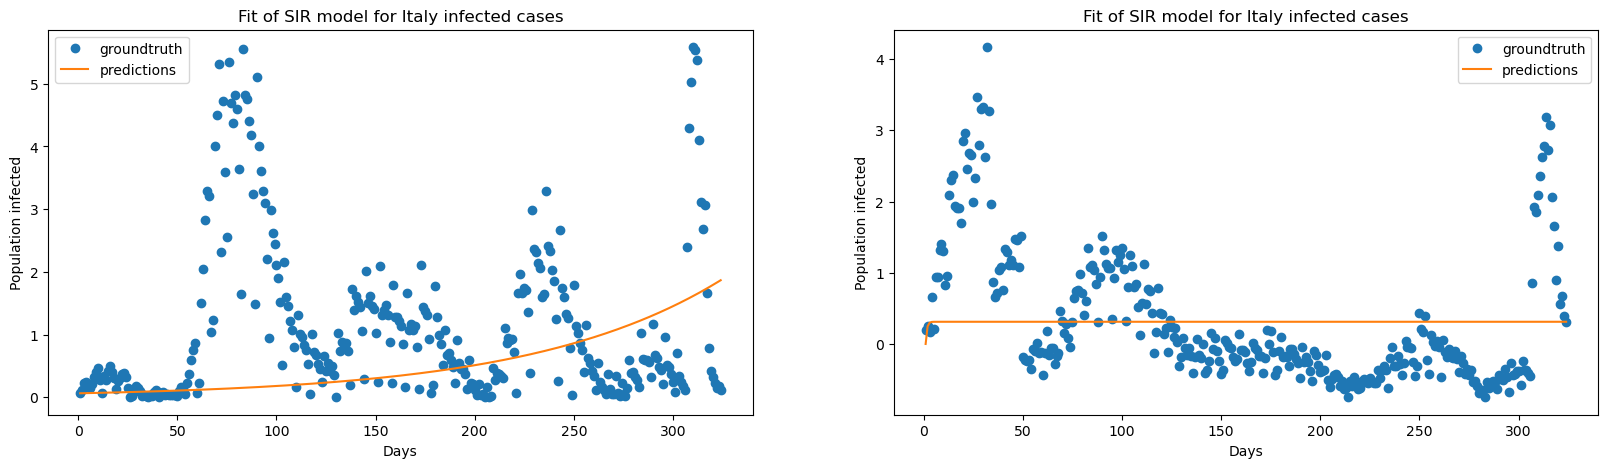

Optimal parameters: beta = 6.1352056154511265  and gamma =  7.722796271096148


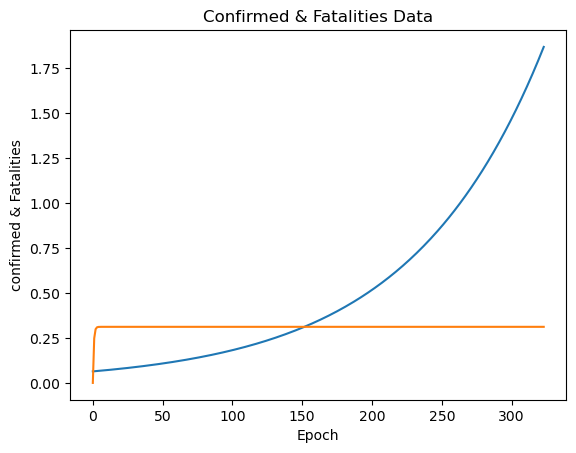

,confirmed,fatalities,date,day
0,0.064065,0.000000,2020-01-31,0
1,0.064737,0.247937,2020-02-01,1
2,0.065417,0.298620,2020-02-02,2
3,0.066103,0.308980,2020-02-03,3
4,0.066797,0.311098,2020-02-04,4
...,...,...,...,...
319,1.790386,0.311642,2020-12-15,319
320,1.809172,0.311642,2020-12-16,320
321,1.828154,0.311642,2020-12-17,321
322,1.847336,0.311642,2020-12-18,322


In [10]:
deal_SIR(italy_df, "Italy", population_)

330610570.0


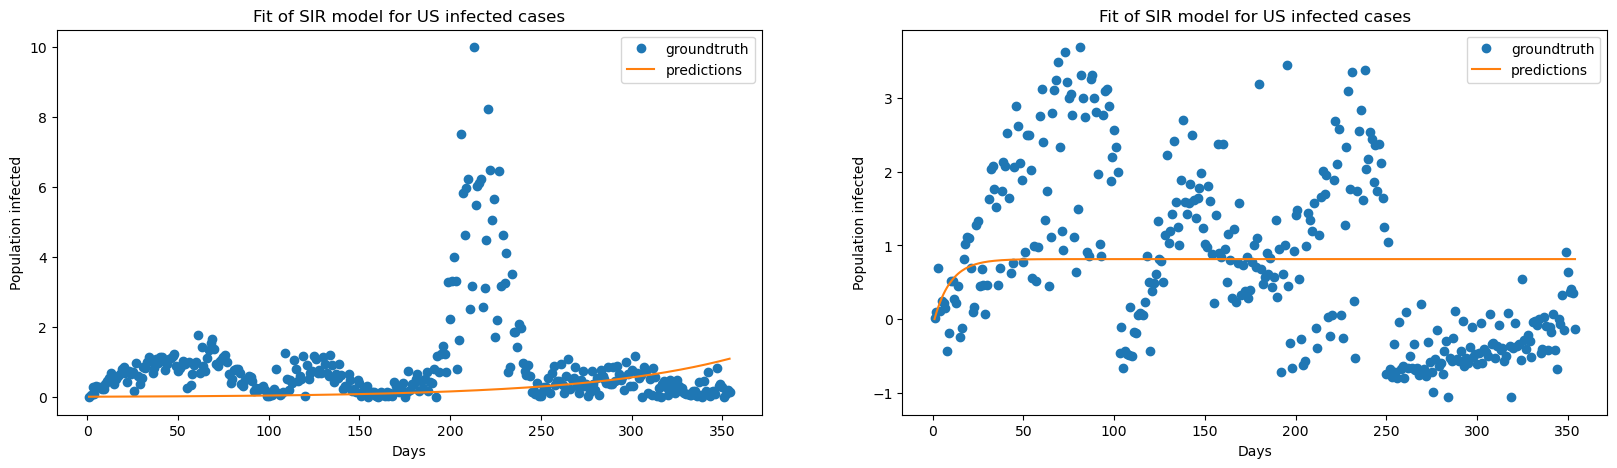

Optimal parameters: beta = 6.067190116431254  and gamma =  6.175704608538267


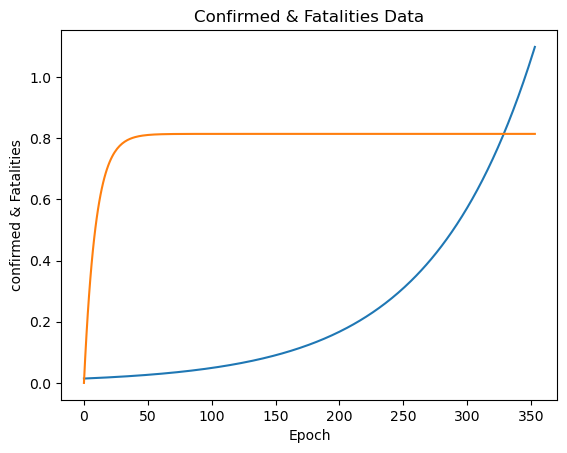

,confirmed,fatalities,date,day
0,0.014306,0.000000,2020-01-22,0
1,0.014483,0.083728,2020-01-23,1
2,0.014663,0.158845,2020-01-24,2
3,0.014844,0.226238,2020-01-25,3
4,0.015028,0.286701,2020-01-26,4
...,...,...,...,...
349,1.045776,0.814200,2021-01-05,349
350,1.058716,0.814200,2021-01-06,350
351,1.071815,0.814200,2021-01-07,351
352,1.085077,0.814200,2021-01-08,352


In [11]:
deal_SIR(us_df, "US", population_)

7777967034.0


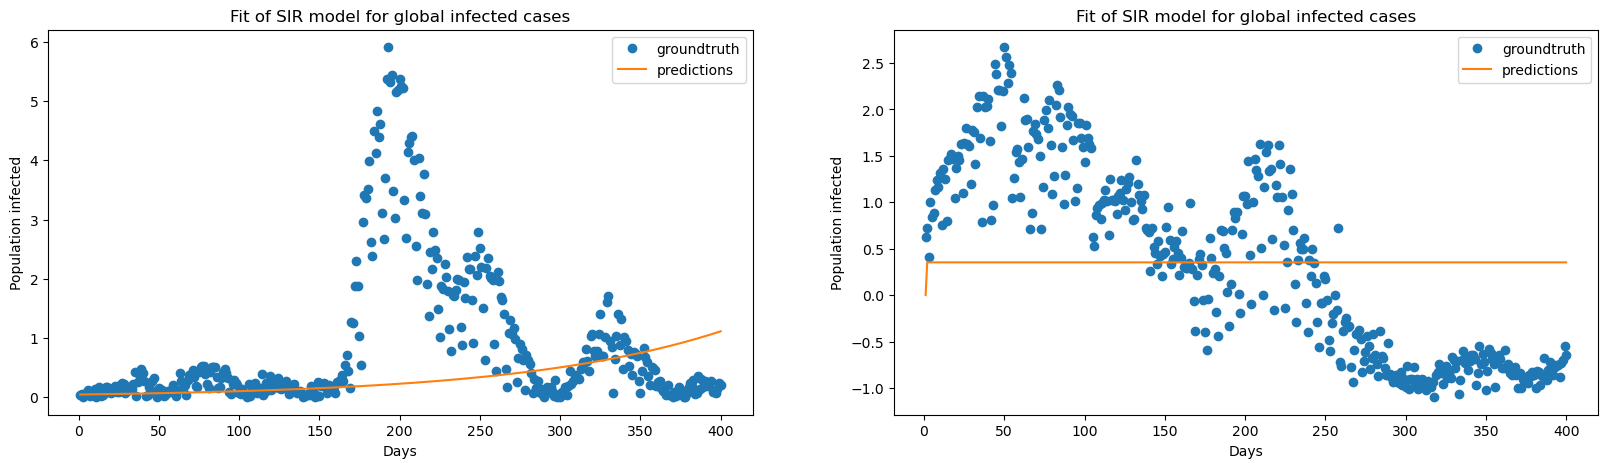

Optimal parameters: beta = 72.20211256828316  and gamma =  83.49387774324103


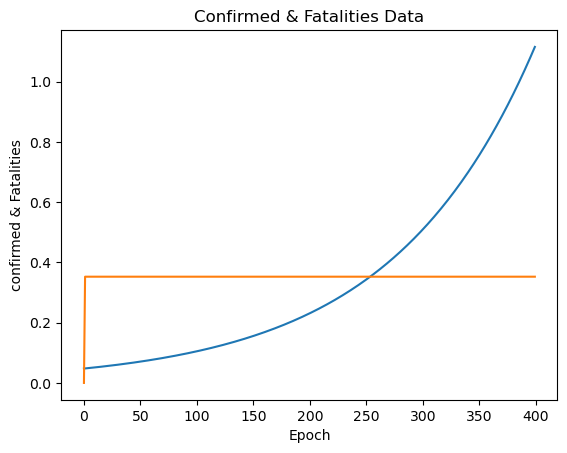

,confirmed,fatalities,date,day
0,0.047671,0.000000,2020-01-22,0
1,0.048049,0.352488,2020-01-23,1
2,0.048431,0.352492,2020-01-24,2
3,0.048815,0.352492,2020-01-25,3
4,0.049202,0.352492,2020-01-26,4
...,...,...,...,...
395,1.080293,0.352492,2021-02-20,395
396,1.088861,0.352492,2021-02-21,396
397,1.097498,0.352492,2021-02-22,397
398,1.106203,0.352492,2021-02-23,398


In [12]:
deal_SIR(global_df, "global", population_)

### GAN

In [13]:
class Gan(object):
    def __init__(self, sequence_length, g_len, country="US", length = 15):
        self.sequence_length = sequence_length
        self.g_len = g_len
        self.length = length
        self.country = country
        
        self.noiseSet = False #设定是 使用SIR作为噪音数据 还是  使用随机噪声
           
    def dealNoist(self, df):
        
        begin_prediction = df[df['day'] == (df.iloc[-1, -1] - self.length + 1)]['day'].values[0]
        
        rows = df[df['day'] < begin_prediction]
        confirmed_trend = [float(x) for x in rows.confirmed.values]
        mu = 0
        sigma = 0.12
        for i in range(rows.shape[0]):
            confirmed_trend.append(random.gauss(mu,sigma))
        self.noiseData = np.reshape(np.asarray(confirmed_trend), [rows.shape[0] * 2, 1])
        
#         self.noiseData = np.reshape(np.asarray(confirmed_trend), [rows.shape[0], 1])
        self.noiseSet = True #使用SIR作为噪音数据
        return self.noiseData
        
    def trainData(self, tamp_df, country, colName = "confirmed_trend"):
        self.country = country
        begin_prediction = tamp_df[tamp_df['day'] == (tamp_df.iloc[-1, -1] - self.length + 1)]['day'].values[0]
        rows = tamp_df[tamp_df['day'] < begin_prediction]
        trend_list = []
        for i in range(0, len(rows)):
            if i + self.sequence_length < len(rows):
                confirmed_trend = [float(x) for x in rows[i:i+self.sequence_length].confirmed.values]
                fatality_trend = [float(x) for x in rows[i:i+self.sequence_length].fatalities.values]

                trend_list.append({"confirmed_trend":confirmed_trend,
                                "fatality_trend":fatality_trend})

        trend_df = pd.DataFrame(trend_list)
        trend_df["temporal_inputs"] = [np.asarray([trends[colName]]) 
                                       for idx,trends in trend_df.iterrows()]
        trend_df = shuffle(trend_df)
        data = np.asarray(np.transpose(np.reshape(np.asarray([np.asarray(x) for x in trend_df["temporal_inputs"].values]),
                                                              (trend_df.shape[0],1,self.sequence_length)),(0,2,1) )).astype(np.float32)
        return data
    
    def discriminator(self, input_layer, reuse=False, trainable=True):
         with tf.variable_scope("discriminator", reuse=reuse):
        
            conv = tf.layers.conv2d(input_layer, 64, [1, 1], padding='SAME')
#             conv = tf.layers.batch_normalization(conv, trainable=trainable)
            conv = tf.nn.relu(conv)
            
            conv = tf.layers.conv2d(conv, 128, [1, 1], padding='SAME')
#             conv = tf.layers.batch_normalization(conv, trainable=trainable)
            conv = tf.nn.relu(conv)
            
            conv = tf.layers.conv2d(conv, 256, [2, 1], padding='SAME')
#             conv = tf.layers.batch_normalization(conv, trainable=trainable)
            conv = tf.nn.relu(conv)
            
            conv = tf.layers.conv2d(conv, 512, [2, 1], padding='SAME')
#             conv = tf.layers.batch_normalization(conv, trainable=trainable)
            conv = tf.nn.relu(conv)
            
            flat = tf.layers.flatten(conv)
            dense = tf.layers.dense(flat, 1)
            
        
            return dense
    
    def generator(self, input_layer, reuse=False, trainable=True):
        with tf.variable_scope("generator", reuse=reuse):
            
            dense = tf.layers.dense(input_layer, self.sequence_length * 1024 * 1)
            
            flat  = tf.reshape(dense, [-1, self.sequence_length, 1, 1024])
#             flat = tf.layers.batch_normalization(flat, trainable=trainable)
            flat = tf.nn.relu(flat)
            
            tconv = tf.layers.conv2d_transpose(flat, 512, kernel_size=[1, 1], strides=[1, 1], padding='SAME')
#             tconv = tf.layers.batch_normalization(tconv, trainable=trainable)
            tconv = tf.nn.relu(tconv)
            
            tconv = tf.layers.conv2d_transpose(tconv, 256, kernel_size=[1, 1], strides=[1, 1], padding='SAME')
#             tconv = tf.layers.batch_normalization(tconv, trainable=trainable)
            tconv = tf.nn.relu(tconv)
            
            tconv = tf.layers.conv2d_transpose(tconv, 128, kernel_size=[1, 1], strides=[1, 1], padding='SAME')
#             tconv = tf.layers.batch_normalization(tconv, trainable=trainable)
            tconv = tf.nn.relu(tconv)
    
            tconv = tf.layers.conv2d_transpose(tconv, 1, kernel_size=[1, 1], strides=[1, 1], padding='SAME')
#             tconv = tf.layers.batch_normalization(tconv, trainable=trainable)
            tconv = tf.nn.relu(tconv, name="gen_data")
    
        return tconv
    
    def plot_loss(self):
        fig = plt.figure(figsize=[20, 5])

        plt.subplot(121)
        plt.plot(self.all_ds)
        plt.title('Loss over epochs')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['d_loss'], loc='best')

        plt.subplot(122)
        plt.plot(self.all_gs)
        plt.title('Loss over epochs for the number of cases')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['g_loss', 'Validation'], loc='best')

        plt.show()
        
    def train(self, data, iter_epoch=20, 
              learning_rate=0.00002, beta1=0.5):
        tf.reset_default_graph()

        x = tf.placeholder(tf.float32, shape=[None, self.sequence_length, 1, 1], name="Data")
        noise = tf.placeholder(tf.float32, shape=[None, self.g_len], name="Noise")
        
        G = self.generator(noise, reuse=False)
        print(G.shape)
        D_real = self.discriminator(x, reuse=False)
        D_fake = self.discriminator(G, reuse=True)

        D_real_loss = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(logits=D_real, labels=tf.ones_like(D_real)))
        D_fake_loss = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(logits=D_fake, labels=tf.zeros_like(D_fake)))
        D_loss = D_real_loss + D_fake_loss

        G_loss = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(logits=D_fake, labels=tf.ones_like(D_fake)))

        t_vars = tf.trainable_variables()
        d_vars = [var for var in t_vars if var.name.startswith('discriminator')]
        g_vars = [var for var in t_vars if var.name.startswith('generator')]
        with tf.control_dependencies(tf.get_collection(tf.GraphKeys.UPDATE_OPS)):
            g_op = tf.train.AdamOptimizer(learning_rate=learning_rate,
                                          beta1=beta1).minimize(G_loss, var_list=g_vars)
            d_op = tf.train.AdamOptimizer(learning_rate=learning_rate,
                                          beta1=beta1).minimize(D_loss, var_list=d_vars)
        print("network build success")
        
        self.all_ds = []
        self.all_gs = []
        saver = tf.train.Saver()
        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())
            for i in range(iter_epoch):
                total_batch = int(data.shape[0])
                
                nsl = self.random_noise(total_batch)
                ds, _ = sess.run([D_loss, d_op], feed_dict={x: data, noise: nsl})
                
                for j in range(3):
                    ns2 = np.random.uniform(low=-1, high=1, size=[total_batch, self.g_len])
                    gs, _ = sess.run([G_loss, g_op], feed_dict={x: data, noise: ns2})
                
                self.all_ds.append(ds)
                self.all_gs.append(gs)
                print("Iter: {}      d_loss: {:.4}       g_loss: {:.4}".format(i, ds, gs))
                
            saver.save(sess, "./gan_model/" + self.country + "_model")
            
    def random_noise(self, num):
        if self.noiseSet == True:
            bk  = [random.randint(0,self.noiseData.shape[0] - 1) for _ in range(num * self.g_len)]
            ns1 = np.reshape(self.noiseData[bk, :], [num, self.g_len])
        else:
            ns1 = np.random.uniform(low=-1, high=1, size=[num, self.g_len])
        return ns1
            
    def predict(self, num):
        
        ns1 = self.random_noise(num)
        
        saver = tf.train.Saver()
        with tf.Session() as sess:
            saver.restore(sess, "./gan_model/" + self.country + "_model")

            graph = tf.get_default_graph()
            noise = graph.get_tensor_by_name("Noise:0")
            data_ = graph.get_tensor_by_name("generator/gen_data:0")
            feed_dict ={noise : ns1}
            data = sess.run(data_,feed_dict)
        return np.reshape(data, [data.shape[0], data.shape[1], data.shape[2]])


In [14]:
def StandData(df):
    scaler1 = StandardScaler()
    scaler2 = StandardScaler()

    confirmed_ = np.array(df.confirmed.fillna(0))
    fatalities_ = np.array(df.fatalities.fillna(0))

    scaler1.fit(confirmed_.reshape(-1, 1))
    confirmed_ = scaler1.transform(confirmed_.reshape(-1, 1)).reshape(-1)
    
    scaler2.fit(fatalities_.reshape(-1, 1))
    fatalities_ = scaler2.transform(fatalities_.reshape(-1, 1)).reshape(-1)
    
    df["confirmed"] = confirmed_
    df["fatalities"] = fatalities_
    idex = list(range(0, df.shape[0]))
    df["day"] = idex
    return df

In [15]:
def ganData(seq, lens, df, name, noiseSet = True, 
            colName = "confirmed_trend", iter_epoch=10):
    temp_data = df.copy()
    temp_data = temp_data.iloc[:-30]
    print(temp_data.shape)
    gan = Gan(seq, lens)
    temp_data = StandData(temp_data)
#     temp_data = log2_(df)
    
    data = gan.trainData(temp_data, name, colName)
    data = np.reshape(data[:, :, :], [data.shape[0], data.shape[1], data.shape[2], 1])
    
    if noiseSet == True:
        sirData = deal_SIR(temp_data.copy(), name)
        noise = gan.dealNoist(sirData)
    
    gan.train(data, iter_epoch=iter_epoch)
    gan.plot_loss()
    return gan

In [16]:
tf.compat.v1.disable_eager_execution()

In [ ]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan = ganData(61, 60, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "fatality_trend", iter_epoch=500) #confirmed_trend   fatality_trend

In [ ]:
gdata = gan.predict(1000)
np.save('ganDataNew/stand_russia_del30_fatality_noise_1000',gdata )  #confirmed  fatality
gdata.shape

(1102, 19)
145922010.0


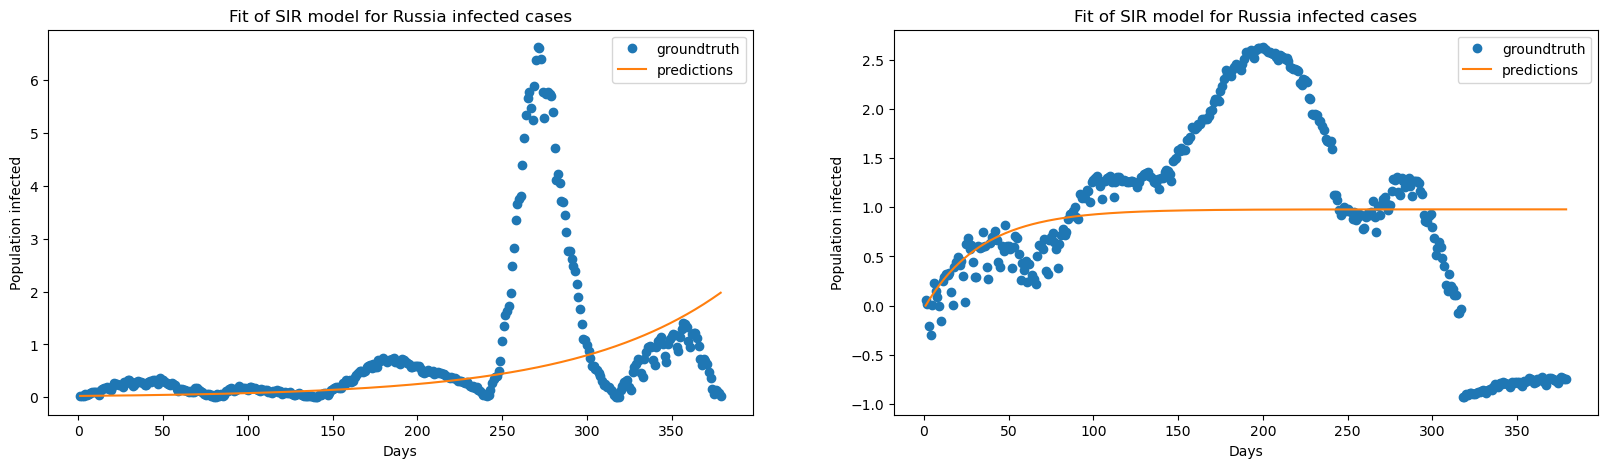

Optimal parameters: beta = 1.1321498529430636  and gamma =  1.1618017037631672


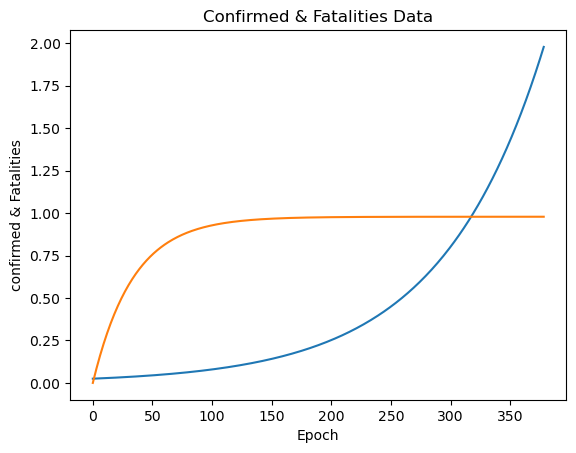

C:\Users\user\AppData\Local\Temp\ipykernel_22412\3576750696.py:75: UserWarning:

`tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.

C:\Users\user\AppData\Local\Temp\ipykernel_22412\3576750696.py:81: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\user\AppData\Local\Temp\ipykernel_22412\3576750696.py:85: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\user\AppData\Local\Temp\ipykernel_22412\3576750696.py:89: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2DTranspose` instead.

C:\Users\user\AppData\Local\Temp\ipykernel_22412\3576750696.py:93: UserWarning:

`tf.layers.conv2d_transpose` is deprecated and will be remov

(None, 61, 1, 1)
network build success
Iter: 0      d_loss: 1.391       g_loss: 0.6931
Iter: 1      d_loss: 1.388       g_loss: 0.6931
Iter: 2      d_loss: 1.385       g_loss: 0.6929
Iter: 3      d_loss: 1.382       g_loss: 0.6926
Iter: 4      d_loss: 1.379       g_loss: 0.6923
Iter: 5      d_loss: 1.376       g_loss: 0.6918
Iter: 6      d_loss: 1.373       g_loss: 0.6912
Iter: 7      d_loss: 1.371       g_loss: 0.6905
Iter: 8      d_loss: 1.369       g_loss: 0.6894
Iter: 9      d_loss: 1.366       g_loss: 0.6882
Iter: 10      d_loss: 1.365       g_loss: 0.6867
Iter: 11      d_loss: 1.363       g_loss: 0.6848
Iter: 12      d_loss: 1.362       g_loss: 0.6827
Iter: 13      d_loss: 1.361       g_loss: 0.6801
Iter: 14      d_loss: 1.36       g_loss: 0.6775
Iter: 15      d_loss: 1.36       g_loss: 0.6744
Iter: 16      d_loss: 1.36       g_loss: 0.671
Iter: 17      d_loss: 1.361       g_loss: 0.6673
Iter: 18      d_loss: 1.362       g_loss: 0.6635
Iter: 19      d_loss: 1.363       g_loss: 0.

In [ ]:
%%time
## noiseSet = True  数据AN
## noiseSet = False 随机噪声数据
gan2 = ganData(61, 60, russia_df.copy(), 
              "Russia", noiseSet = True, 
              colName = "confirmed_trend", iter_epoch=500) #confirmed_trend   fatality_trend


In [ ]:
gdata2 = gan2.predict(1000)
np.save('ganDataNew/stand_russia_del30_confirmed_noise_1000',gdata2 )  #confirmed  fatality
gdata2.shape

In [984]:
global_df = deal_global_df(population_, all_df, "World", "global")         ####
us_df     = deal_country_data(population_, all_df, "United States", "US")  ####
italy_df  = deal_country_data(population_, all_df, "Italy", "Italy")    ####
france_df = deal_country_data(population_, all_df, "France", "France")  ####
japan_df  = deal_country_data(population_, all_df, "Japan", "Japan")    ####

china_df   = deal_country_data(population_, all_df, "China", "China")
spain_df   = deal_country_data(population_, all_df, "Spain", "Spain")
uk_df      = deal_country_data(population_, all_df, "United Kingdom", "United Kingdom")
germany_df = deal_country_data(population_, all_df, "Germany", "Germany")
koread_df = deal_country_data(population_, all_df, "South Korea", "South Korea")

canada_df = deal_country_data(population_, all_df, "Canada", "Canada")
india_df = deal_country_data(population_, all_df, "India", "India")
russia_df = deal_country_data(population_, all_df, "Russia", "Russia")

global_df_ = addCsvDelNa(global_df)
us_df_     = addCsvDelNa(us_df)

italy_df_  = addCsvDelNa(italy_df)
# france_df_ = addCsvDelNa(france_df)
# japan_df_  = addCsvDelNa(japan_df)

# italy_df_  = addCsvRepNa(italy_df)
france_df_ = addCsvRepNa(france_df)
japan_df_  = addCsvRepNa(japan_df)

# china_df_   = addCsvRepNa(china_df)
# spain_df_   = addCsvRepNa(spain_df)
# uk_df_      = addCsvRepNa(uk_df)
# germany_df_ = addCsvRepNa(germany_df)

china_df_   = addCsvDelNa(china_df)
spain_df_   = addCsvDelNa(spain_df)
uk_df_      = addCsvDelNa(uk_df)
germany_df_ = addCsvDelNa(germany_df)



In [ ]:
# stand_global_+_del80_confirmed_noise_61_1000  SIR作为噪音数据 生成数据
# stand_global_+_del80_confirmed_SJ_noise_61_1000  随机噪声作为噪音数据 生成数据
